EDA

#1. Total Revenue per Category (Bar Chart)

In [8]:
import pandas as pd

# Load the csv file
df_merged = pd.read_csv('merged.csv')

# Optional: Verify the data loaded correctly
print(df_merged.head())

  item_purchased       size   color     category  season  review_rating  \
0        T-shirt         XL   Olive     Clothing  Winter            3.2   
1     Sunglasses  Free Size   White  Accessories  Spring            3.9   
2          Shirt          M   Black     Clothing  Winter            3.1   
3         Gloves  Free Size     Red  Accessories    Fall            4.2   
4        Jewelry  Free Size  Yellow  Accessories  Spring            3.6   

   purchase_amount discount_applied   shipping_type payment_method  \
0             68.0               No        Standard           Cash   
1             84.0              Yes   Free Shipping     Debit Card   
2             50.0               No  2-Day Shipping           Cash   
3             75.0               No    Store Pickup           Cash   
4             80.0               No    Store Pickup    Credit Card   

   customer_id   age  gender subscription_status  previous_purchases  \
0         2701  22.0  Female                  No        

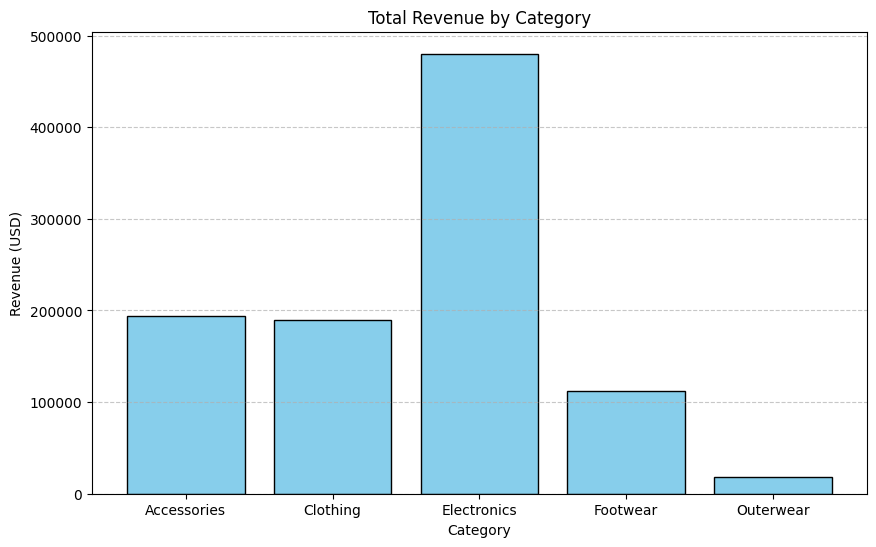

In [9]:
import matplotlib.pyplot as plt

category_revenue = df_merged.groupby('category')['purchase_amount'].sum()
plt.figure(figsize=(10, 6))
plt.bar(category_revenue.index, category_revenue.values, color='skyblue', edgecolor='black')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2.Rating Distribution (Histogram)

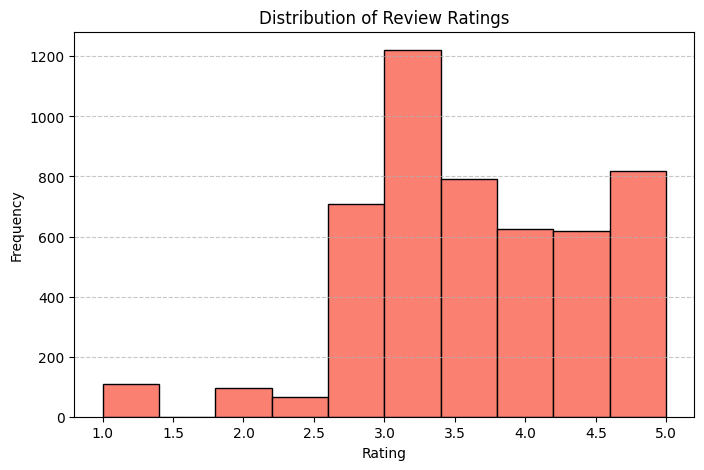

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df_merged['review_rating'].dropna(), bins=10, color='salmon', edgecolor='black')
plt.title('Distribution of Review Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 3. Purchase Amount Distribution (Box Plot)

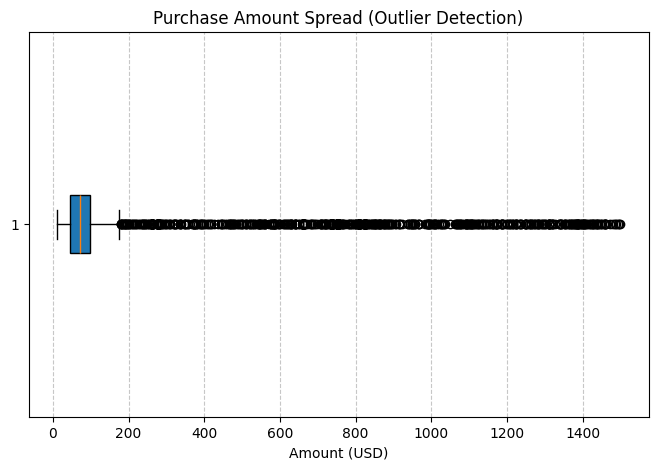

In [11]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_merged['purchase_amount'].dropna(), vert=False, patch_artist=True)
plt.title('Purchase Amount Spread (Outlier Detection)')
plt.xlabel('Amount (USD)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [12]:
# 4. Revenue vs. Review Rating (Scatter Plot)

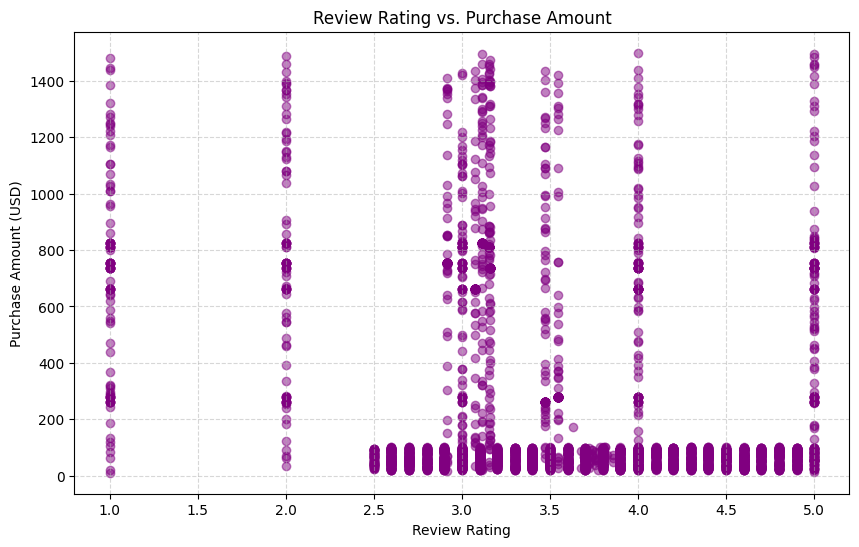

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df_merged['review_rating'], df_merged['purchase_amount'], alpha=0.5, color='purple')
plt.title('Review Rating vs. Purchase Amount')
plt.xlabel('Review Rating')
plt.ylabel('Purchase Amount (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [14]:
# 5. Shipping Type Popularity (Pie Chart)


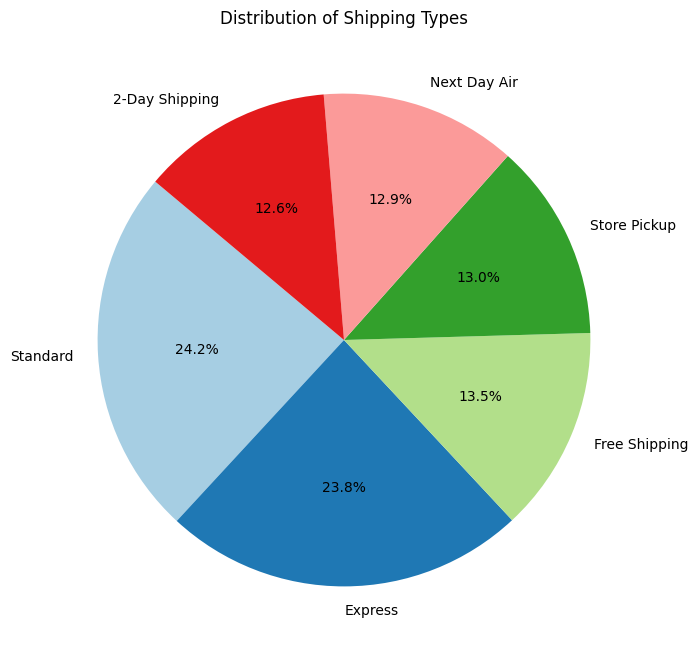

In [15]:
shipping_counts = df_merged['shipping_type'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(shipping_counts, labels=shipping_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Shipping Types')
plt.show()

In [16]:
6

6

C:\Users\sai baba\AppData\Local\Temp\ipykernel_10480\2018352106.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=df_merged['category'].unique(), patch_artist=True)


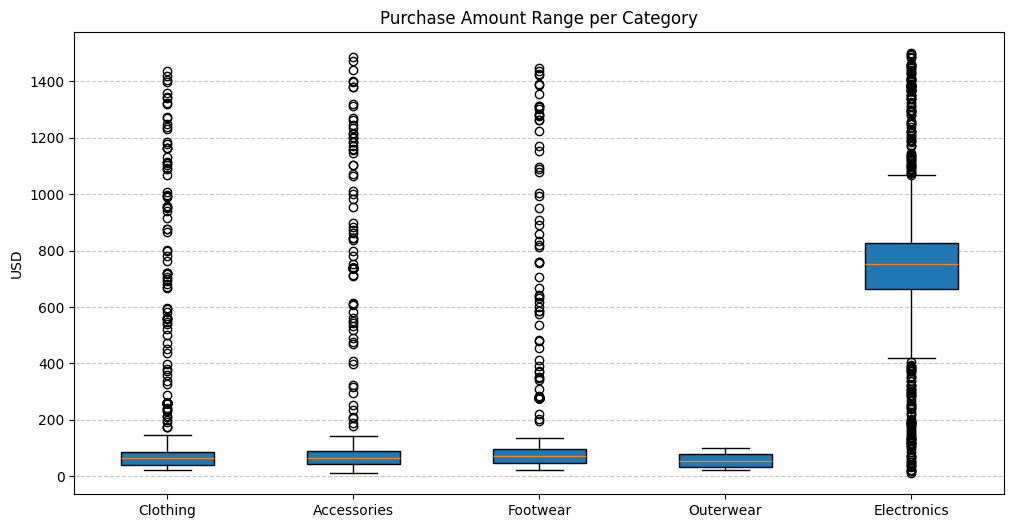

In [17]:
data_to_plot = [df_merged[df_merged['category'] == cat]['purchase_amount'].dropna() for cat in df_merged['category'].unique()]
plt.figure(figsize=(12, 6))
plt.boxplot(data_to_plot, labels=df_merged['category'].unique(), patch_artist=True)
plt.title('Purchase Amount Range per Category')
plt.ylabel('USD')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
# 7.Seasonal Sales (Bar Chart)

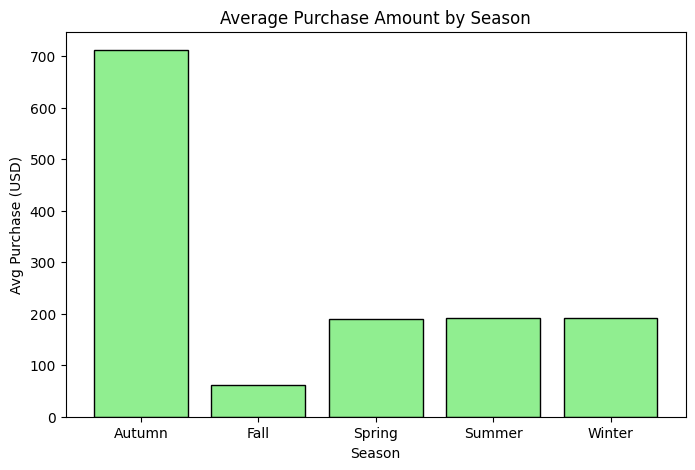

In [19]:
season_sales = df_merged.groupby('season')['purchase_amount'].mean()
plt.figure(figsize=(8, 5))
plt.bar(season_sales.index, season_sales.values, color='lightgreen', edgecolor='black')
plt.title('Average Purchase Amount by Season')
plt.xlabel('Season')
plt.ylabel('Avg Purchase (USD)')
plt.show()

In [21]:
# Discount Impact (Side-by-Side Comparison)

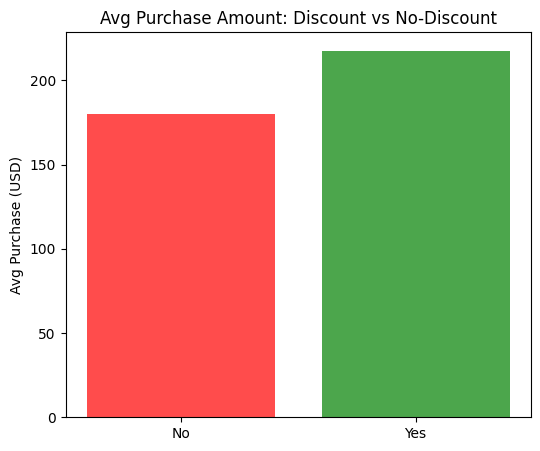

In [22]:
discount_effect = df_merged.groupby('discount_applied')['purchase_amount'].mean()
plt.figure(figsize=(6, 5))
plt.bar(discount_effect.index, discount_effect.values, color=['red', 'green'], alpha=0.7)
plt.title('Avg Purchase Amount: Discount vs No-Discount')
plt.ylabel('Avg Purchase (USD)')
plt.show()

In [23]:
# 9. Top 10 Most Purchased Items (Horizontal Bar)

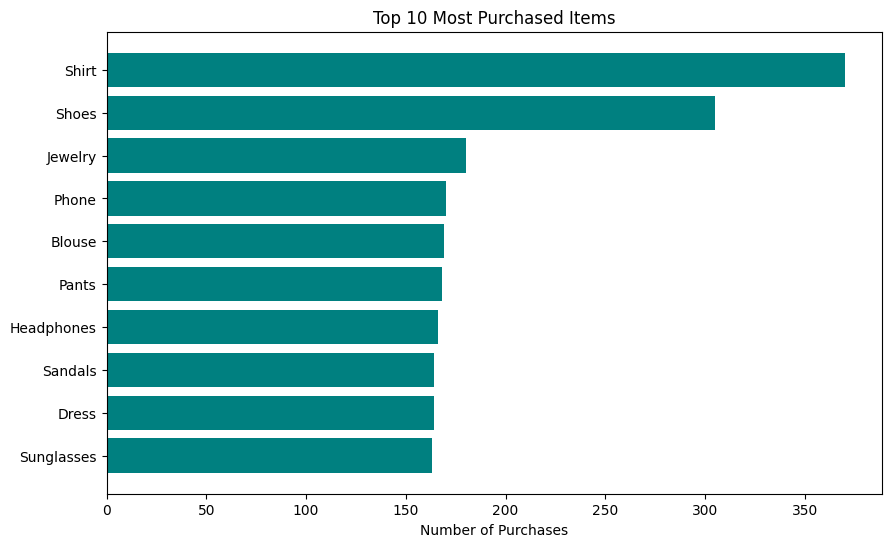

In [24]:
top_items = df_merged['item_purchased'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_items.index, top_items.values, color='teal')
plt.title('Top 10 Most Purchased Items')
plt.xlabel('Number of Purchases')
plt.gca().invert_yaxis() # Puts the highest value on top
plt.show()

In [25]:
# 10. Payment Method Frequency (Bar Chart)

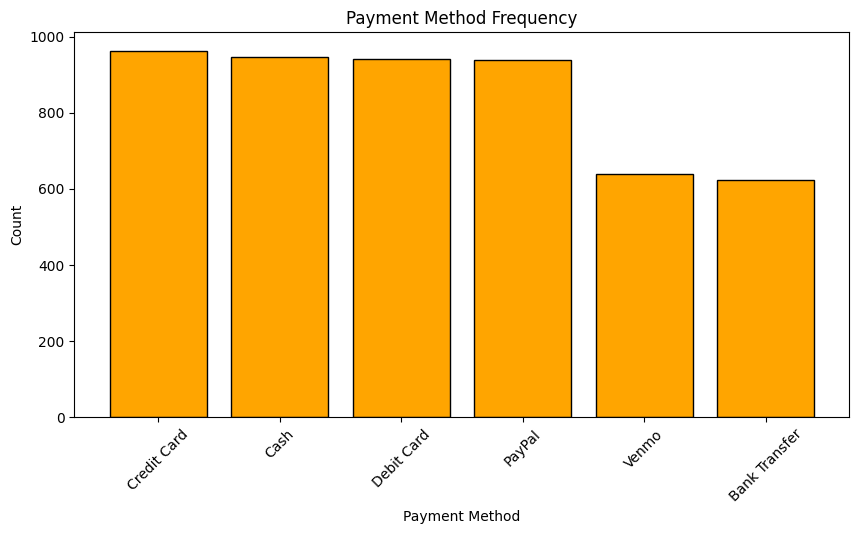

In [26]:
pay_counts = df_merged['payment_method'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(pay_counts.index, pay_counts.values, color='orange', edgecolor='black')
plt.title('Payment Method Frequency')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [27]:
# This chart follows the Pareto Principle; it highlights that a small subset of our inventory is responsible for the vast majority of customer demand. We should optimize supply chain and stock levels specifically for these items to maximize efficiency."


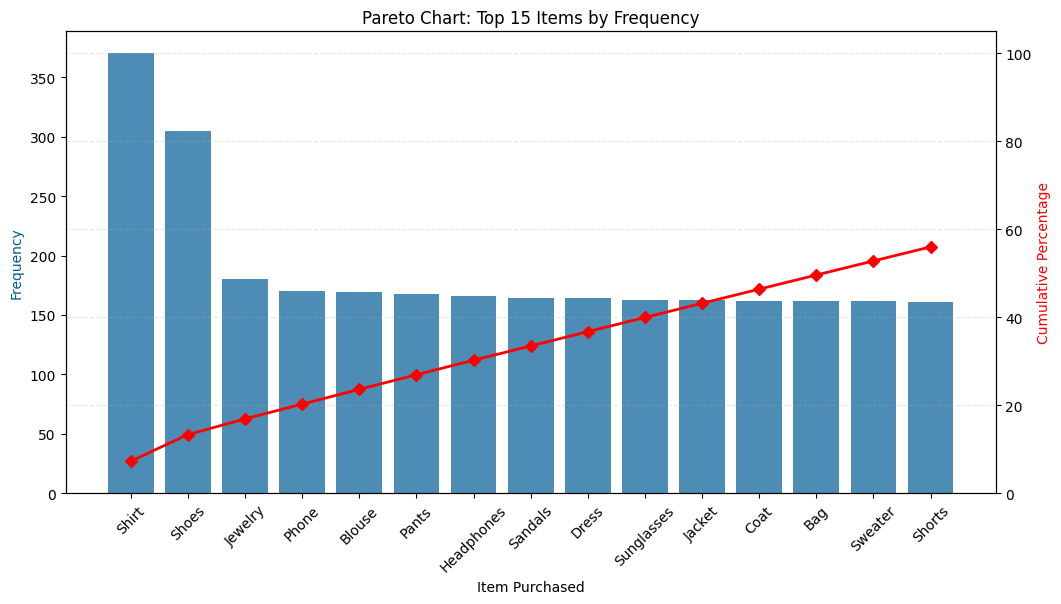

In [28]:
# 1. Prepare data: Count frequency of each item and sort descending
item_counts = df_merged['item_purchased'].value_counts()
df_pareto = pd.DataFrame({'count': item_counts})
df_pareto['cum_percentage'] = df_pareto['count'].cumsum() / df_pareto['count'].sum() * 100

# 2. Setup the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# 3. Bar chart (Primary Axis)
ax1.bar(df_pareto.index[:15], df_pareto['count'][:15], color='#005b96', alpha=0.7)
ax1.set_xlabel('Item Purchased')
ax1.set_ylabel('Frequency', color='#005b96')
ax1.tick_params(axis='x', rotation=45)

# 4. Line chart (Secondary Axis)
ax2 = ax1.twinx()
ax2.plot(df_pareto.index[:15], df_pareto['cum_percentage'][:15], color='red', marker='D', linewidth=2)
ax2.set_ylabel('Cumulative Percentage', color='red')
ax2.set_ylim(0, 105)

plt.title('Pareto Chart: Top 15 Items by Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()